# 19 — Heterogeneous Treatment Effects: the Landscape and the Evaluation Problem
**Prerequisites:** causal_inference_course/11_heterogeneous_effects_ml.ipynb (meta-learners,
causal forests, DML derivations — this notebook does not repeat them); 18_uplift_modeling.ipynb
(the marketing-terminology version of this same problem).
**Connects to:** 20_causal_forests.ipynb, 21_double_machine_learning.ipynb, 22_meta_learners.ipynb
(each is a deep dive into one estimator family sketched here), 23_policy_learning.ipynb (what to
do once you have a validated CATE estimate).

## Narrative thread
```
Why CATE, restated for a business audience -> map of the estimator landscape -> the central
problem: no ground truth -> honesty/sample-splitting as the organizing principle -> validating
CATE estimates without knowing the truth (R-loss, GATES, Qini)
```

## Why this notebook exists

`causal_inference_course/11` builds each CATE estimator from its identifying assumptions up.
This notebook is the **map**, not another derivation: it orients you across the whole landscape
of $\hat\tau(x) = \mathbb{E}[Y(1)-Y(0)\mid X=x]$ estimators, explains why **evaluating** a CATE
estimator is a fundamentally different (and harder) problem than evaluating a prediction model,
and sets up the shared vocabulary — honesty, orthogonality, cross-fitting — that 20–23 each
build on for one estimator family.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(7)

## The estimator landscape

| Family | Idea | Strength | Weakness | Deep dive |
|---|---|---|---|---|
| **Meta-learners** (S/T/X/R) | Reduce CATE to one or more standard supervised-learning problems | Reuse any ML model off the shelf; easy to implement | Bias-variance tradeoffs differ sharply by learner (see `22`) | `22_meta_learners.ipynb` |
| **Causal forests / GRF** | Recursively partition covariate space to maximize *treatment-effect* heterogeneity, with honest splitting | Nonparametric, gives asymptotically valid CIs per point (Wager & Athey, 2018) | Needs enough data per leaf; less flexible functional form than boosting-based learners | `20_causal_forests.ipynb` |
| **DML / R-learner** | Partial out nuisance functions via Neyman-orthogonal moments, then fit CATE on residuals | Robust to slow (even $n^{1/4}$) nuisance-model convergence rates | Two nuisance models to get right; sensitive to regularization bias if not orthogonalized correctly | `21_double_machine_learning.ipynb` |
| **Policy trees / direct policy optimization** | Skip CATE estimation; directly optimize the *treatment rule* | Matches the real objective (welfare), not an intermediate one (CATE accuracy) | Doesn't give you a CATE number, only a decision — less useful for e.g. reporting expected lift by segment | `23_policy_learning.ipynb` |

All of them answer the same underlying question posed in `11`: given a randomized or
unconfounded observational study, how do we let $\tau(X)$ vary flexibly with covariates instead
of collapsing to a single ATE?

## The central problem: there is no ground truth

Standard ML model selection compares $\hat f(X)$ to observed $Y$ via a held-out loss. CATE
estimation cannot do this because **$\tau_i = Y_i(1) - Y_i(0)$ is never jointly observed** for
any unit — this is the fundamental problem of causal inference, and it means we cannot compute
$\text{MSE} = \mathbb{E}[(\hat\tau(X) - \tau(X))^2]$ directly on real data, ever. Three
consequences follow, and they explain almost every methodological choice in 20–23:

1. **We can only validate estimators in simulation** where $\tau(X)$ is simulated and known
(as in `11`, `18`, and every notebook here) — real-data benchmarks always require *some*
proxy.
2. **On real data we need proxies for the loss** that use only observables: the R-loss
(residual-on-residual, from the R-learner moment condition), or group-level checks like
**GATES** (Group Average Treatment Effects — bucket by $\hat\tau$ and check whether realized
outcomes actually differ across buckets in a held-out randomized sample) or the
**Qini/uplift curve** (`18`) — all of these substitute a *rank* or *group-average* comparison
for a pointwise one, because ranks and group averages ARE identified from observable data even
though individual $\tau_i$ is not.
3. **Honest sample-splitting becomes mandatory, not optional.** If the same data used to fit
$\hat\tau(\cdot)$ is also used to evaluate it, apparent heterogeneity is inflated by overfitting
— the model can find "heterogeneity" in noise. Every valid CATE evaluation procedure in this
module partitions data into a part that fits the model and a disjoint part that evaluates it.

In [2]:
# ── Simulated CATE ground truth: the sandbox we validate methods against ──
def make_cate_data(n, seed):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, (n, 5))
    e = 0.5  # randomized
    W = rng.binomial(1, e, n)
    tau = 1.5 * (X[:, 0] > 0) + 0.75 * X[:, 1] * (X[:, 2] > 0)   # true heterogeneous CATE
    mu0 = 1.0 + 0.5 * X[:, 3] + 0.3 * X[:, 4] ** 2
    Y = mu0 + W * tau + rng.normal(0, 1, n)
    return pd.DataFrame(X, columns=[f'X{i}' for i in range(5)]).assign(W=W, Y=Y, tau_true=tau)

df = make_cate_data(10_000, seed=3)
train, test = train_test_split(df, test_size=0.4, random_state=0)
Xcols = [c for c in df.columns if c.startswith('X')]
print(df[['W', 'Y', 'tau_true']].describe().round(2))

              W         Y  tau_true
count  10000.00  10000.00  10000.00
mean       0.51      1.80      0.75
std        0.50      1.45      0.96
min        0.00     -3.53     -1.50
25%        0.00      0.81      0.00
50%        1.00      1.75      0.75
75%        1.00      2.74      1.50
max        1.00      7.21      3.00


## Honesty in practice, and the R-loss as a model-selection tool

**Honest sample-splitting** (Athey & Imbens, 2016; formalized for forests by Wager & Athey, 2018)
splits the training fold again: one half determines the model structure (e.g. which splits a
tree makes, or which hyperparameters a grid search picks), a disjoint half estimates the leaf-
or region-level treatment effects used at prediction time. This trades a little bias (using less
data per step) for valid, non-overfit uncertainty quantification and for defensible held-out
comparison.

For **model selection between competing CATE estimators** (which learner? which
hyperparameters?) on real data, use the **R-loss** implied by the R-learner's own moment
condition (Nie & Wager, 2021; Chernozhukov et al., 2018 orthogonal moments — see `21`):
$$
\widehat{L}_R(\hat\tau) = \frac{1}{n}\sum_i \big[(Y_i - \hat\mu(X_i)) - (W_i - \hat e(X_i))\,\hat\tau(X_i)\big]^2 ,
$$
computed on a **held-out fold**, with $\hat\mu, \hat e$ estimated out-of-fold (cross-fitted, see
`21`). Lower R-loss favors the better CATE estimator — and unlike raw MSE against $\tau_i$, every
quantity in this formula ($Y$, $W$, $X$) is observed. It is *not* an unbiased estimate of the
true $\mathbb{E}[(\hat\tau-\tau)^2]$ (it has an extra irreducible-noise term that's constant
across models), but differences in R-loss across competing $\hat\tau$ models are still valid for
*ranking* estimators, which is all model selection needs.

In [3]:
# ── R-loss as a model-selection criterion between two CATE estimators ─────
def crossfit_nuisances(df, Xcols, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    mu_hat = np.zeros(len(df)); e_hat = np.zeros(len(df))
    idx = df.index.values
    for tr_idx, te_idx in kf.split(df):
        tr, te = df.iloc[tr_idx], df.iloc[te_idx]
        mu_m = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=30, random_state=seed).fit(tr[Xcols], tr['Y'])
        e_m = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=30, random_state=seed).fit(tr[Xcols], tr['W'])
        mu_hat[te_idx] = mu_m.predict(te[Xcols])
        e_hat[te_idx] = np.clip(e_m.predict(te[Xcols]), 0.05, 0.95)
    return mu_hat, e_hat

def r_loss(df, Xcols, tau_hat, seed=0):
    mu_hat, e_hat = crossfit_nuisances(df, Xcols, seed=seed)
    resid_y = df['Y'].values - mu_hat
    resid_w = df['W'].values - e_hat
    return np.mean((resid_y - resid_w * tau_hat) ** 2)

# Two competing CATE estimators fit on train, R-loss evaluated on test
def t_learner_tau(train, test, Xcols):
    m1 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=30, random_state=1).fit(
        train.loc[train.W == 1, Xcols], train.loc[train.W == 1, 'Y'])
    m0 = RandomForestRegressor(n_estimators=300, max_depth=4, min_samples_leaf=30, random_state=2).fit(
        train.loc[train.W == 0, Xcols], train.loc[train.W == 0, 'Y'])
    return m1.predict(test[Xcols]) - m0.predict(test[Xcols])

def constant_effect_tau(train, test, Xcols):
    # naive "no heterogeneity" baseline: single ATE for everyone
    ate = train.loc[train.W == 1, 'Y'].mean() - train.loc[train.W == 0, 'Y'].mean()
    return np.full(len(test), ate)

tau_t = t_learner_tau(train, test, Xcols)
tau_const = constant_effect_tau(train, test, Xcols)

loss_t = r_loss(test, Xcols, tau_t)
loss_const = r_loss(test, Xcols, tau_const)
mse_t = np.mean((tau_t - test['tau_true'].values) ** 2)
mse_const = np.mean((tau_const - test['tau_true'].values) ** 2)

print(f"T-learner        R-loss = {loss_t:.3f}   (true MSE = {mse_t:.3f})")
print(f"Constant-effect  R-loss = {loss_const:.3f}   (true MSE = {mse_const:.3f})")
print("\nR-loss correctly ranks the T-learner ahead of the naive constant-effect model,")
print("agreeing with the (normally unobservable) true MSE we can only compute because this is a simulation.")

T-learner        R-loss = 1.219   (true MSE = 0.239)
Constant-effect  R-loss = 1.372   (true MSE = 0.925)

R-loss correctly ranks the T-learner ahead of the naive constant-effect model,
agreeing with the (normally unobservable) true MSE we can only compute because this is a simulation.


## GATES: a second, more interpretable validation

**Group Average Treatment Effects** buckets test units into (e.g.) quintiles of $\hat\tau(X)$
and estimates the *realized* ATE within each bucket using the randomized outcome data — this
average-within-bucket quantity **is** identified, even though the individual $\tau_i$ is not. If
the CATE estimator has real signal, realized ATEs should increase monotonically from the bottom
to the top bucket. This is the estimator-agnostic generalization of the uplift curve from `18`
(which is the cumulative/rank version of the same idea) and is often reported as a simple table
or bar chart to communicate heterogeneity to a non-technical audience.

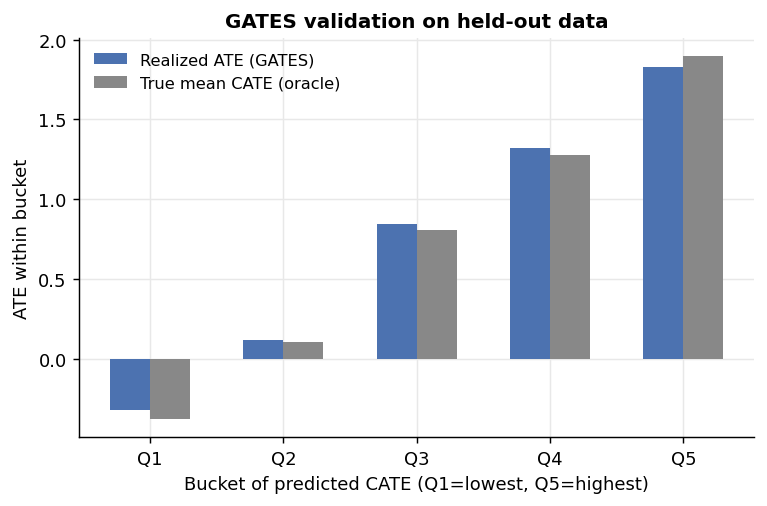

bucket
Q1   -0.322
Q2    0.116
Q3    0.846
Q4    1.320
Q5    1.832
dtype: float64


In [4]:
# ── GATES: bucket by predicted CATE, check realized ATE increases monotonically ─
test = test.copy()
test['tau_hat'] = tau_t
test['bucket'] = pd.qcut(test['tau_hat'], 5, labels=[f'Q{i+1}' for i in range(5)])

def realized_ate(g):
    return g.loc[g.W == 1, 'Y'].mean() - g.loc[g.W == 0, 'Y'].mean()

gates = test.groupby('bucket', observed=True).apply(realized_ate, include_groups=False)
true_gates = test.groupby('bucket', observed=True)['tau_true'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(5)
ax.bar(x - 0.15, gates.values, width=0.3, label='Realized ATE (GATES)', color='#4C72B0')
ax.bar(x + 0.15, true_gates.values, width=0.3, label='True mean CATE (oracle)', color='#888888')
ax.set_xticks(x); ax.set_xticklabels(gates.index)
ax.set_xlabel('Bucket of predicted CATE (Q1=lowest, Q5=highest)')
ax.set_ylabel('ATE within bucket')
ax.set_title('GATES validation on held-out data')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(gates.round(3))

## Summary: the organizing principle for 20–23

Every notebook that follows in this module is an instance of the same recipe:

1. Split data honestly (fit / evaluate on disjoint samples, or cross-fit nuisances).
2. Estimate $\tau(X)$ with an orthogonalized or honestly-split procedure so first-order errors
in nuisance estimation don't bias the CATE.
3. Validate with a proxy loss that only uses observables (R-loss, GATES, Qini) — never trust an
apparent-heterogeneity number that wasn't computed this way.

`20` goes deep on causal forests (the honest-splitting nonparametric family), `21` goes deep on
DML/R-learner (the orthogonal-moments family), `22` compares all four meta-learners head to
head, and `23` asks what to *do* once you trust a CATE estimate.

## References

| Reference | Contribution |
|---|---|
| Athey & Imbens (2016, *PNAS*) | Honest causal trees; the sample-splitting principle |
| Wager & Athey (2018, *JASA*) | Causal forests, asymptotic normality, pointwise CIs |
| Chernozhukov, Chetverikov, Demirer, Duflo, Hansen, Newey & Robins (2018, *Econometrics Journal*) | Neyman-orthogonal moments, DML, cross-fitting |
| Künzel, Sekhon, Bickel & Yu (2019, *PNAS*) | Meta-learner taxonomy and bias-variance analysis |
| Nie & Wager (2021, *Biometrika*) | R-learner and the R-loss as a model-selection criterion |
| Radcliffe & Surry (2011) | GATES/Qini-style group validation, from the uplift-modeling literature |
